# LineEdge — end-to-end walkthrough

This notebook drives the **real** LineEdge modules — nothing here is a
reimplementation. Every cell imports from `app/` (and `scripts/market_sim.py`)
and runs the same code paths the service and dashboard use.

> ### All market data in this notebook is SIMULATED
> There is no bookmaker integration anywhere in this repository. Prices come
> from `scripts/market_sim.py`, a synthetic generator, and are read back through
> `MockOddsClient`, which loads JSON fixtures off disk. Treat every price,
> edge, EV figure and CLV number below as made up. **Nothing here is a real
> odds feed, a real edge, or financial advice.**

The pipeline we walk through:

1. Generate a synthetic multi-book market (`scripts/market_sim.py`)
2. Ingest it (`app/ingestion/mock_provider.py`)
3. Resolve feed names to canonical entities (`app/engine/resolver.py`)
4. Devig a market with the No-Vig Power Method (`app/engine/math_utils.py`)
5. Detect +EV edges (`app/services/detection_service.py`)
6. Persist and read back (`app/storage/`)
7. Close out the market and record CLV (`app/storage/auditor.py`)
8. Chart the results

## 0. Setup

In [1]:
import json, random, sys, warnings
from datetime import datetime, timedelta
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repo root.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "app").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sqlalchemy import text

warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

WORK_DIR = REPO_ROOT / ".demo_tmp"
WORK_DIR.mkdir(exist_ok=True)
ASSETS = REPO_ROOT / "docs" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("python    :", sys.version.split()[0])

repo root : C:\Users\thoma\sports-betting-app
python    : 3.12.10


In [2]:
# The real application modules. No logic is reimplemented in this notebook.
from app.core.config import Settings
from app.engine.math_utils import (
    american_to_decimal,
    decimal_to_implied_prob,
    strip_vig_power_method,
    calculate_ev,
    kelly_criterion,
)
from app.engine.resolver import EntityResolver, TeamCanonical, GameCanonical
from app.ingestion.mock_provider import MockOddsClient
from app.services.detection_service import EdgeDetectionService, EdgeCache
from app.storage.auditor import EdgeAuditor
from app.storage.database import DatabaseManager
from app.storage.models import DetectedEdge
from app.storage.repository import seed_if_empty, load_resolver
from scripts.market_sim import build_universe, build_cycle_fixture, entity_uuid, BOOK_VIG

print("app modules imported OK")

app modules imported OK


### Chart styling

One small helper so every figure in the notebook shares a palette and looks like
the same system. Categorical hues are assigned in a fixed order (never cycled),
and the diverging good/bad pair is reserved for CLV outcomes only.

In [3]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
GOOD, BAD, NEUTRAL = "#1baf7a", "#e34948", "#8a8985"
INK, INK_MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 160,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelcolor": INK_MUTED, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.edgecolor": "#d7d6d1", "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.autolayout": True,
})

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None, axis="y"):
    ax.set_title(title, loc="left", pad=18 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=INK_MUTED, va="bottom")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, axis=axis, alpha=0.9)
    ax.set_axisbelow(True)
    return ax

## 1. Generate a synthetic market

`scripts/market_sim.py` builds a small universe of canonical teams and games,
then quotes each game with six fictional books. Each book has its own margin
(overround) and its own pricing noise, which is what creates the price
dispersion the detector hunts for.

Everything below this line is invented. It is not a market.

In [4]:
SEED = 20260725
rng = random.Random(SEED)
NOW = datetime.utcnow().replace(microsecond=0)

seed_payload, games = build_universe(NOW)

print(f"canonical teams : {len(seed_payload['teams'])}")
print(f"canonical games : {len(seed_payload['games'])}\n")
for g in games:
    print(f"  {g['home']:<20} vs {g['away']:<20}  "
          f"feed names: {g['home_feed_name']!r} / {g['away_feed_name']!r}")
print("\nbook overrounds (vig):")
for book, vig in BOOK_VIG.items():
    print(f"  {book:<12} {vig:.3f}  ->  {(vig - 1) * 100:.1f}% margin")

canonical teams : 6
canonical games : 3

  New York Rangers     vs Los Angeles Kings     feed names: 'NY Rangers' / 'LA Kings'
  New York Knicks      vs Boston Celtics        feed names: 'Knicks' / 'Boston Celtics'
  Kansas City Chiefs   vs Buffalo Bills         feed names: 'KC Chiefs' / 'Bills'

book overrounds (vig):
  Pinnacle     1.014  ->  1.4% margin
  DraftKings   1.042  ->  4.2% margin
  FanDuel      1.045  ->  4.5% margin
  BetMGM       1.050  ->  5.0% margin
  Caesars      1.020  ->  2.0% margin
  BetRivers    1.018  ->  1.8% margin


In [5]:
# One polling snapshot: every book quotes both sides of every h2h market.
fixture = build_cycle_fixture(games, cycle=0, sim_time=NOW, rng=rng)
FIXTURE_PATH = WORK_DIR / "notebook_cycle.json"
FIXTURE_PATH.write_text(json.dumps(fixture, indent=2), encoding="utf-8")

print(json.dumps(fixture[0]["bookmakers"][0], indent=2)[:600] + "\n...")

{
  "key": "pinnacle",
  "title": "Pinnacle",
  "last_update": "2026-07-26T01:14:00",
  "markets": [
    {
      "key": "h2h",
      "outcomes": [
        {
          "name": "NY Rangers",
          "price": -124
        },
        {
          "name": "LA Kings",
          "price": 117
        }
      ]
    }
  ]
}
...


## 2. Ingest through the real provider interface

`MockOddsClient` implements the same `OddsProvider` interface a live feed would.
It parses the fixture into pydantic `OddsEvent` models — identical objects to the
ones the detection service consumes.

In [6]:
provider = MockOddsClient(str(FIXTURE_PATH))
events = await provider.get_odds()

print(f"{len(events)} events ingested, types: {type(events[0]).__name__}\n")

evt = events[0]
rows = []
for bm in evt.bookmakers:
    market = next(m for m in bm.markets if m.key == "h2h")
    prices = {o.name: o.price for o in market.outcomes}
    rows.append({"bookmaker": bm.title, **{f"{k} (US)": int(v) for k, v in prices.items()}})

print(f"{evt.home_team} vs {evt.away_team}  |  sport={evt.sport_key}  "
      f"|  starts {evt.commence_time:%Y-%m-%d %H:%M} UTC   [SIMULATED]")
pd.DataFrame(rows).set_index("bookmaker")

3 events ingested, types: OddsEvent

NY Rangers vs LA Kings  |  sport=icehockey_nhl  |  starts 2026-07-26 05:14 UTC   [SIMULATED]


,NY Rangers (US),LA Kings (US)
bookmaker,,
Pinnacle,-124,117
DraftKings,-153,129
FanDuel,-138,115
BetMGM,-176,142
Caesars,-146,134
BetRivers,-132,122


## 3. Entity resolution

Feeds disagree about names: `"NY Rangers"`, `"New York Rangers"`, `"Rangers"`.
`EntityResolver` collapses them onto canonical UUIDs with a two-tier strategy —
an exact hash lookup first, then a RapidFuzz `token_sort_ratio` fallback above a
similarity threshold. `resolve_game` additionally requires both teams to resolve
*and* the start time to land within a 6-hour window.

In [7]:
from uuid import UUID

teams = [TeamCanonical(id=UUID(t["id"]), name=t["name"], aliases=t["aliases"])
         for t in seed_payload["teams"]]
canon_games = [GameCanonical(id=UUID(g["id"]), home_team_id=UUID(g["home_team_id"]),
                             away_team_id=UUID(g["away_team_id"]),
                             start_time=datetime.fromisoformat(g["start_time"]))
               for g in seed_payload["games"]]
resolver = EntityResolver(teams, canon_games)

name_by_id = {str(t.id): t.name for t in teams}
probe_names = ["New York Rangers", "NY Rangers", "  rangers  ", "LA Kings",
               "Los Angeles Kings", "Boston Celtcs", "KC Chiefs", "Toronto Maple Leafs"]

res = []
for n in probe_names:
    tid = resolver.resolve_team(n)
    exact = resolver._sanitize(n) in resolver._exact_team_map
    res.append({
        "feed name": n,
        "tier": "-" if tid is None else ("1 exact" if exact else "2 fuzzy"),
        "resolved to": name_by_id.get(str(tid), "UNRESOLVED"),
    })
pd.DataFrame(res)

,feed name,tier,resolved to
0,New York Rangers,1 exact,New York Rangers
1,NY Rangers,1 exact,New York Rangers
2,rangers,1 exact,New York Rangers
3,LA Kings,1 exact,Los Angeles Kings
4,Los Angeles Kings,1 exact,Los Angeles Kings
5,Boston Celtcs,2 fuzzy,Boston Celtics
6,KC Chiefs,1 exact,Kansas City Chiefs
7,Toronto Maple Leafs,-,UNRESOLVED


In [8]:
# Games resolve only when both teams resolve and the kickoff time lines up.
for e in events:
    gid = resolver.resolve_game(e.home_team, e.away_team, e.commence_time)
    print(f"{e.home_team:<12} vs {e.away_team:<16} -> {gid}")

# Same fixture, but 3 days off: outside the 6-hour window, so it must NOT resolve.
stale = resolver.resolve_game(events[0].home_team, events[0].away_team,
                              events[0].commence_time + timedelta(days=3))
print(f"\nsame matchup shifted +3 days -> {stale}  (rejected by the 6h window)")

NY Rangers   vs LA Kings         -> 00000101-0000-4000-8000-000000000101
Knicks       vs Boston Celtics   -> 00000102-0000-4000-8000-000000000102
KC Chiefs    vs Bills            -> 00000103-0000-4000-8000-000000000103

same matchup shifted +3 days -> None  (rejected by the 6h window)


## 4. The devigging math, step by step

A bookmaker's quoted prices imply probabilities that sum to **more than 1**. The
excess is the margin (overround / vig). To ask "is this price good?" you first
have to strip that margin out to get a *fair* probability.

LineEdge uses the **No-Vig Power Method**: find the exponent $k$ such that

$$\sum_i p_i^{\,k} = 1$$

where $p_i$ are the raw implied probabilities. `strip_vig_power_method` solves
for $k$ with Newton–Raphson. Unlike the naive multiplicative method
($p_i / \sum p$), the power method removes proportionally *more* margin from
longshots, which matches how books actually price the tails (favourite–longshot
bias).

Let's run it on one real market from the fixture above.

In [9]:
evt = events[0]
book = next(b for b in evt.bookmakers if b.title == "BetMGM")   # a high-margin book
market = next(m for m in book.markets if m.key == "h2h")

american = [(o.name, o.price) for o in market.outcomes]
decimals = [american_to_decimal(int(p)) for _, p in american]
implied  = [decimal_to_implied_prob(d) for d in decimals]
overround = sum(implied)

print(f"Market: {evt.home_team} vs {evt.away_team}  |  book: {book.title}  [SIMULATED]\n")
for (name, us), dec, p in zip(american, decimals, implied):
    print(f"  {name:<16} {us:>+5}  ->  decimal {dec:.4f}  ->  implied {p:.4%}")
print(f"\n  sum of implied probabilities = {overround:.6f}")
print(f"  overround (vig)              = {(overround - 1) * 100:.3f}%")

Market: NY Rangers vs LA Kings  |  book: BetMGM  [SIMULATED]



  NY Rangers       -176.0  ->  decimal 1.5682  ->  implied 63.7681%
  LA Kings         +142.0  ->  decimal 2.4200  ->  implied 41.3223%

  sum of implied probabilities = 1.050904
  overround (vig)              = 5.090%


In [10]:
fair = strip_vig_power_method(implied)

# math_utils returns the devigged probabilities; recover the exponent k it solved
# for, since fair_i = p_i ** k  =>  k = ln(fair_i) / ln(p_i).
k = np.log(fair[0]) / np.log(implied[0])

naive = [p / overround for p in implied]   # the multiplicative method, for contrast

print(f"solved exponent k = {k:.6f}   (k = 1 would be a vig-free market)")
print(f"check: sum(p_i ** k) = {sum(p ** k for p in implied):.12f}\n")

pd.DataFrame({
    "outcome":        [n for n, _ in american],
    "raw implied":    implied,
    "power-method fair": fair,
    "naive fair":     naive,
    "power - naive (pp)": [(f - n) * 100 for f, n in zip(fair, naive)],
    "fair decimal":   [1 / f for f in fair],
}).set_index("outcome").round(6)

solved exponent k = 1.080249   (k = 1 would be a vig-free market)
check: sum(p_i ** k) = 1.000000000000



,raw implied,power-method fair,naive fair,power - naive (pp),fair decimal
outcome,,,,,
NY Rangers,0.637681,0.615068,0.606793,0.827534,1.625836
LA Kings,0.413223,0.384932,0.393207,-0.827534,2.597862


### From fair probability to an edge

With a fair probability in hand, a price is +EV when

$$EV = p_{fair}\,(d - 1) - (1 - p_{fair})$$

is positive, where $d$ is the decimal price on offer. `calculate_ev` does exactly
this; `kelly_criterion` then sizes the (hypothetical) stake.

The detection service does not devig one book in isolation — it averages the
implied probabilities **across all books** to build a consensus, devigs *that*,
and then compares every individual book's price against the consensus fair line.
That's what the next cell reproduces.

In [11]:
market_key = "h2h"
all_probs, bookie_lines = [], []
for bm in evt.bookmakers:
    m = next((x for x in bm.markets if x.key == market_key), None)
    if not m:
        continue
    outcomes = {o.name: american_to_decimal(int(o.price)) for o in m.outcomes}
    bookie_lines.append((bm.title, outcomes))
    all_probs.append([decimal_to_implied_prob(d) for d in outcomes.values()])

avg_probs   = [float(np.mean([p[i] for p in all_probs])) for i in range(len(all_probs[0]))]
fair_probs  = strip_vig_power_method(avg_probs)
fair_decs   = [1 / p for p in fair_probs]
outcome_names = list(bookie_lines[0][1].keys())

print("consensus across all six books  [SIMULATED]")
for n, a, f, d in zip(outcome_names, avg_probs, fair_probs, fair_decs):
    print(f"  {n:<16} avg implied {a:.4%}  ->  fair {f:.4%}  (fair decimal {d:.4f})")

EV_THRESHOLD = 0.02
rows = []
for bname, outcomes in bookie_lines:
    for i, (oname, price) in enumerate(outcomes.items()):
        ev = calculate_ev(price, fair_probs[i])
        rows.append({
            "bookmaker": bname, "outcome": oname, "decimal": price,
            "fair decimal": fair_decs[i], "EV": ev,
            "Kelly (1/4)": kelly_criterion(price, fair_probs[i], 0.25),
            "flagged": ev > EV_THRESHOLD,
        })
ev_table = pd.DataFrame(rows).sort_values("EV", ascending=False)
ev_table.head(10).style.format({"decimal": "{:.3f}", "fair decimal": "{:.3f}",
                                "EV": "{:+.2%}", "Kelly (1/4)": "{:.3%}"})

consensus across all six books  [SIMULATED]
  NY Rangers       avg implied 58.9715%  ->  fair 57.4840%  (fair decimal 1.7396)
  LA Kings         avg implied 44.2275%  ->  fair 42.5160%  (fair decimal 2.3521)


,bookmaker,outcome,decimal,fair decimal,EV,Kelly (1/4),flagged
0,Pinnacle,NY Rangers,1.806,1.740,+3.84%,1.191%,True
7,BetMGM,LA Kings,2.420,2.352,+2.89%,0.509%,True
10,BetRivers,NY Rangers,1.758,1.740,+1.03%,0.341%,False
9,Caesars,LA Kings,2.340,2.352,-0.51%,0.000%,False
4,FanDuel,NY Rangers,1.725,1.740,-0.86%,0.000%,False
3,DraftKings,LA Kings,2.290,2.352,-2.64%,0.000%,False
8,Caesars,NY Rangers,1.685,1.740,-3.14%,0.000%,False
2,DraftKings,NY Rangers,1.654,1.740,-4.94%,0.000%,False
11,BetRivers,LA Kings,2.220,2.352,-5.61%,0.000%,False
1,Pinnacle,LA Kings,2.170,2.352,-7.74%,0.000%,False


### Arbitrage check

A two-way arbitrage exists when the best available price on each side has
implied probabilities summing to **below 1** — i.e. you can back both sides and
book a profit regardless of the result. The same implied-probability primitives
answer this directly.

In [12]:
best = {}
for bname, outcomes in bookie_lines:
    for oname, price in outcomes.items():
        if oname not in best or price > best[oname][1]:
            best[oname] = (bname, price)

arb_sum = sum(decimal_to_implied_prob(p) for _, p in best.values())
for oname, (bname, price) in best.items():
    print(f"  best {oname:<16} {price:.4f} @ {bname:<12} "
          f"(implied {decimal_to_implied_prob(price):.4%})")
print(f"\n  sum of best implied = {arb_sum:.6f}")
if arb_sum < 1.0:
    print(f"  ARBITRAGE: guaranteed margin of {(1 - arb_sum) * 100:.3f}% of turnover")
else:
    print(f"  no arbitrage: {(arb_sum - 1) * 100:.3f}% above break-even "
          f"(the residual market margin)")

  best NY Rangers       1.8065 @ Pinnacle     (implied 55.3571%)
  best LA Kings         2.4200 @ BetMGM       (implied 41.3223%)

  sum of best implied = 0.966795
  ARBITRAGE: guaranteed margin of 3.321% of turnover


## 5. Run the detection service

`EdgeDetectionService` is the production loop: poll → resolve → devig → EV →
dedupe via `EdgeCache` → persist → close out finished markets. Here we call
`poll_once()` repeatedly against fresh synthetic snapshots to simulate a session,
backdating each cycle's rows so the results form a time series.

In [13]:
DB_PATH = WORK_DIR / "notebook_demo.db"
if DB_PATH.exists():
    DB_PATH.unlink()

seed_path = WORK_DIR / "notebook_entities.json"
seed_path.write_text(json.dumps(seed_payload, indent=2), encoding="utf-8")

settings = Settings(
    db_url=f"sqlite:///{DB_PATH.as_posix()}",
    canonical_seed_path=str(seed_path),
    mock_fixture_path=str(WORK_DIR / "notebook_cycle.json"),
    ev_threshold=EV_THRESHOLD,
)

db = DatabaseManager(settings.db_url)
session = db.get_session()
seed_if_empty(session, str(seed_path))
db_resolver = load_resolver(session)     # resolver rebuilt from the storage layer
session.close()

print(f"db            : {DB_PATH.name}")
print(f"ev_threshold  : {settings.ev_threshold:.2%}")
print(f"cache TTL     : {settings.edge_cache_ttl_minutes} min, "
      f"spike {settings.edge_cache_spike_threshold:.2%}")
print(f"resolver      : {len(db_resolver.teams)} teams / {len(db_resolver.games)} games "
      "loaded back out of SQLite")

db            : notebook_demo.db
ev_threshold  : 2.00%
cache TTL     : 15 min, spike 2.00%
resolver      : 6 teams / 3 games loaded back out of SQLite


In [14]:
import logging
logging.getLogger("app").setLevel(logging.WARNING)

CYCLES, CYCLE_MINUTES = 14, 30
start = NOW - timedelta(minutes=CYCLE_MINUTES * (CYCLES - 1))

for cycle in range(CYCLES):
    sim_time = start + timedelta(minutes=CYCLE_MINUTES * cycle)
    snap = build_cycle_fixture(games, cycle, sim_time, rng)
    Path(settings.mock_fixture_path).write_text(json.dumps(snap, indent=2), encoding="utf-8")

    with db.engine.connect() as conn:
        before = conn.execute(text("SELECT COALESCE(MAX(id), 0) FROM detected_edges")).scalar_one()

    # A fresh service per cycle gives each simulated poll a clean EdgeCache,
    # which is what a long-lived process looks like across a 15-minute TTL.
    svc = EdgeDetectionService(MockOddsClient(settings.mock_fixture_path),
                               db_resolver, db, settings)
    await svc.poll_once()

    with db.engine.begin() as conn:
        conn.execute(text("UPDATE detected_edges SET timestamp_detected = :ts WHERE id > :b"),
                     {"ts": sim_time.isoformat(sep=" "), "b": before})
        n = conn.execute(text("SELECT COUNT(*) FROM detected_edges WHERE id > :b"),
                         {"b": before}).scalar_one()
    print(f"cycle {cycle:>2}  {sim_time:%H:%M}  edges recorded: {n}")

with db.engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM detected_edges")).scalar_one()
print(f"\ntotal edges persisted: {total}")

cycle  0  18:44  edges recorded: 6


cycle  1  19:14  edges recorded: 9


cycle  2  19:44  edges recorded: 7


cycle  3  20:14  edges recorded: 7


cycle  4  20:44  edges recorded: 4


...

cycle  8  22:44  edges recorded: 4


cycle  9  23:14  edges recorded: 6


cycle 10  23:44  edges recorded: 6
cycle 11  00:14  edges recorded: 2


cycle 12  00:44  edges recorded: 5


cycle 13  01:14  edges recorded: 4

total edges persisted: 78


### Deduplication

Without `EdgeCache` the same standing price would be re-recorded on every single
poll. The cache suppresses a repeat write unless the TTL has lapsed or EV has
moved by more than the spike threshold.

In [15]:
cache = EdgeCache(ttl_minutes=15, ev_spike_threshold=0.02)
key = ("game-1", "h2h", "BetMGM")
for ev in [0.031, 0.032, 0.030, 0.058, 0.059]:
    print(f"  EV {ev:.3%}  ->  record? {cache.should_record(*key, ev)}")

  EV 3.100%  ->  record? True
  EV 3.200%  ->  record? False
  EV 3.000%  ->  record? False
  EV 5.800%  ->  record? True
  EV 5.900%  ->  record? False


## 6. Read back through the storage layer

Nothing is read from the in-memory objects above — this queries SQLite through
the same `DatabaseManager` / `DetectedEdge` ORM the dashboard uses.

In [16]:
session = db.get_session()
edges = session.query(DetectedEdge).order_by(DetectedEdge.timestamp_detected).all()

game_label = {}
for g in games:
    game_label[g["id"]] = f"{g['home_feed_name']} v {g['away_feed_name']}"

df = pd.DataFrame([{
    "id": e.id,
    "detected": e.timestamp_detected,
    "game": game_label.get(e.canonical_game_id, e.canonical_game_id[:8]),
    "sport": e.sport,
    "market": e.market_type,
    "bookmaker": e.bookmaker_name,
    "outcome": e.outcome_name,
    "odds_offered": e.odds_offered,
    "fair_odds": e.fair_odds,
    "ev": e.calculated_ev,
    "is_active": e.is_active,
    "closing_line": e.closing_line,
    "clv_pct": e.clv_pct,
} for e in edges])
session.close()

print(f"{len(df)} rows read back from {DB_PATH.name}")
print(f"mean EV {df.ev.mean():+.2%} | max EV {df.ev.max():+.2%} | "
      f"books {df.bookmaker.nunique()} | games {df.game.nunique()}")
df.head(10)

78 rows read back from notebook_demo.db


mean EV +4.36% | max EV +10.18% | books 6 | games 3


,id,detected,game,sport,market,bookmaker,outcome,odds_offered,fair_odds,ev,is_active,closing_line,clv_pct
0,1,2026-07-25 18:44:22,NY Rangers v LA Kings,icehockey_nhl,h2h,DraftKings,LA Kings,2.460000,2.337839,0.052254,True,None,None
1,2,2026-07-25 18:44:22,NY Rangers v LA Kings,icehockey_nhl,h2h,FanDuel,NY Rangers,1.800000,1.747474,0.030058,True,None,None
2,3,2026-07-25 18:44:22,Knicks v Boston Celtics,basketball_nba,h2h,BetRivers,Knicks,2.540000,2.452687,0.035599,True,None,None
3,4,2026-07-25 18:44:22,KC Chiefs v Bills,americanfootball_nfl,h2h,Pinnacle,KC Chiefs,1.952381,1.906368,0.024137,True,None,None
4,5,2026-07-25 18:44:22,KC Chiefs v Bills,americanfootball_nfl,h2h,DraftKings,Bills,2.180000,2.103305,0.036464,True,None,None
5,6,2026-07-25 18:44:22,KC Chiefs v Bills,americanfootball_nfl,h2h,BetRivers,KC Chiefs,2.000000,1.906368,0.049116,True,None,None
6,7,2026-07-25 19:14:22,NY Rangers v LA Kings,icehockey_nhl,h2h,Pinnacle,NY Rangers,1.819672,1.771404,0.027249,True,None,None
7,8,2026-07-25 19:14:22,NY Rangers v LA Kings,icehockey_nhl,h2h,DraftKings,LA Kings,2.530000,2.296338,0.101754,True,None,None
8,9,2026-07-25 19:14:22,Knicks v Boston Celtics,basketball_nba,h2h,Pinnacle,Knicks,2.680000,2.546098,0.052591,True,None,None
9,10,2026-07-25 19:14:22,Knicks v Boston Celtics,basketball_nba,h2h,BetMGM,Boston Celtics,1.694444,1.646789,0.028938,True,None,None


## 7. CLV closeout with `EdgeAuditor`

Closing Line Value is the industry's honesty check: did the price you flagged
beat the price the market actually settled at? `EdgeAuditor.close_out_market`
deactivates the edge, stamps the closing price, and records

```
clv_pct = implied(closing) - implied(offered)
```

A **positive** `clv_pct` means the flagged price was *longer* than the close —
you beat the closing line. The closeout is scoped to a single `outcome_name`,
because comparing a closing price to an edge on the other side of the market
would be meaningless.

The service triggers this automatically for any game whose start time has passed.
We simulate that with one final poll where the NFL game has kicked off (and the
EV threshold is raised out of reach, so this cycle opens no new positions — it
exists purely to capture closing prices).

In [17]:
closing_games = [
    g.model_copy(update={"start_time": g.start_time - timedelta(hours=2)})
    if str(g.id) == entity_uuid(103) else g
    for g in db_resolver.games
]
closing_resolver = EntityResolver(db_resolver.teams, closing_games)
closing_settings = settings.model_copy(update={"ev_threshold": 10.0})

snap = build_cycle_fixture(games, CYCLES, NOW, rng)
Path(settings.mock_fixture_path).write_text(json.dumps(snap, indent=2), encoding="utf-8")

closing_svc = EdgeDetectionService(MockOddsClient(settings.mock_fixture_path),
                                   closing_resolver, db, closing_settings)
await closing_svc.poll_once()

session = db.get_session()
closed = session.query(DetectedEdge).filter(DetectedEdge.closing_line.isnot(None)).all()
clv = pd.DataFrame([{
    "game": game_label.get(e.canonical_game_id, e.canonical_game_id[:8]),
    "bookmaker": e.bookmaker_name, "outcome": e.outcome_name,
    "odds_offered": e.odds_offered, "closing_line": e.closing_line,
    "ev_at_detection": e.calculated_ev, "clv_pct": e.clv_pct,
    "beat_close": e.clv_pct > 0,
} for e in closed])
session.close()

print(f"{len(clv)} edges closed out by the auditor")
print(f"beat the close: {clv.beat_close.sum()} / {len(clv)} "
      f"({clv.beat_close.mean():.1%}) | mean CLV {clv.clv_pct.mean():+.3%}  [SIMULATED]")
clv.sort_values("clv_pct", ascending=False).head(10)

28 edges closed out by the auditor
beat the close: 21 / 28 (75.0%) | mean CLV +2.805%  [SIMULATED]


,game,bookmaker,outcome,odds_offered,closing_line,ev_at_detection,clv_pct,beat_close
22,KC Chiefs v Bills,Pinnacle,Bills,2.42,1.877193,0.027654,0.119487,True
3,KC Chiefs v Bills,Pinnacle,Bills,2.27,1.877193,0.074781,0.092182,True
11,KC Chiefs v Bills,BetMGM,Bills,2.23,1.869565,0.066392,0.086453,True
12,KC Chiefs v Bills,Caesars,Bills,2.15,1.854701,0.028136,0.074054,True
1,KC Chiefs v Bills,DraftKings,Bills,2.18,1.884956,0.036464,0.071801,True
4,KC Chiefs v Bills,DraftKings,Bills,2.16,1.884956,0.022699,0.067553,True
18,KC Chiefs v Bills,Pinnacle,Bills,2.14,1.877193,0.048207,0.065421,True
7,KC Chiefs v Bills,Pinnacle,Bills,2.14,1.877193,0.043345,0.065421,True
16,KC Chiefs v Bills,Pinnacle,Bills,2.14,1.877193,0.036829,0.065421,True
9,KC Chiefs v Bills,BetMGM,Bills,2.12,1.869565,0.033595,0.063186,True


### Calling the auditor directly

For clarity, here is `EdgeAuditor` used on its own against one still-open market —
this is exactly what `_run_clv_closeouts` invokes internally.

In [18]:
session = db.get_session()
open_edge = (session.query(DetectedEdge)
             .filter(DetectedEdge.is_active == True)
             .order_by(DetectedEdge.calculated_ev.desc()).first())

print("before:")
print(f"  {open_edge.bookmaker_name} / {open_edge.outcome_name} @ {open_edge.odds_offered:.4f}"
      f"  active={open_edge.is_active}  closing_line={open_edge.closing_line}  clv={open_edge.clv_pct}")

# Pretend the market closed a little shorter than the price we flagged.
simulated_close = open_edge.odds_offered * 0.96
EdgeAuditor(session).close_out_market(
    game_id=open_edge.canonical_game_id,
    market_type=open_edge.market_type,
    bookmaker_name=open_edge.bookmaker_name,
    closing_odds=simulated_close,
    outcome_name=open_edge.outcome_name,
)
session.refresh(open_edge)
print(f"\nsimulated closing price: {simulated_close:.4f}")
print("after:")
print(f"  active={open_edge.is_active}  closing_line={open_edge.closing_line:.4f}"
      f"  clv_pct={open_edge.clv_pct:+.4%}  -> "
      f"{'beat the close' if open_edge.clv_pct > 0 else 'lost to the close'}")
session.close()

before:
  DraftKings / LA Kings @ 2.5300  active=True  closing_line=None  clv=None

simulated closing price: 2.4288
after:
  active=False  closing_line=2.4288  clv_pct=+1.6469%  -> beat the close


## 8. Charts

Three views of the run: how the flagged edges are distributed, where they came
from, and how they fared against the close. The PNGs are written to
`docs/assets/` for the README.

**Reminder: this is simulated data. These distributions describe a synthetic
market generator, not any real bookmaker.**

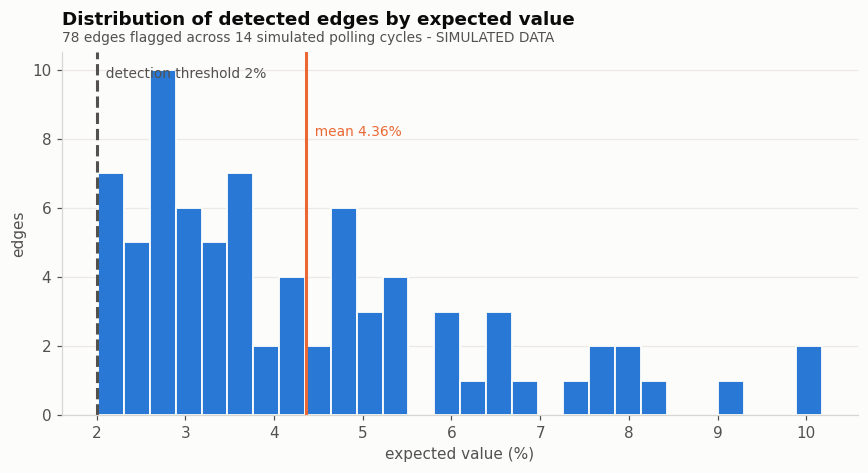

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.4))
vals = df.ev * 100
ax.hist(vals, bins=28, color=SERIES[0], edgecolor=SURFACE, linewidth=1.2)
ax.axvline(EV_THRESHOLD * 100, color=INK_MUTED, lw=2, ls="--")
ax.text(EV_THRESHOLD * 100, ax.get_ylim()[1] * 0.96,
        f"  detection threshold {EV_THRESHOLD:.0%}", color=INK_MUTED,
        fontsize=9, va="top")
ax.axvline(vals.mean(), color=SERIES[1], lw=2)
ax.text(vals.mean(), ax.get_ylim()[1] * 0.80, f"  mean {vals.mean():.2f}%",
        color=SERIES[1], fontsize=9, va="top")
finish(ax, "Distribution of detected edges by expected value",
       f"{len(df)} edges flagged across {CYCLES} simulated polling cycles - SIMULATED DATA",
       "expected value (%)", "edges")
plt.savefig(ASSETS / "notebook_edge_distribution.png", bbox_inches="tight")
plt.show()

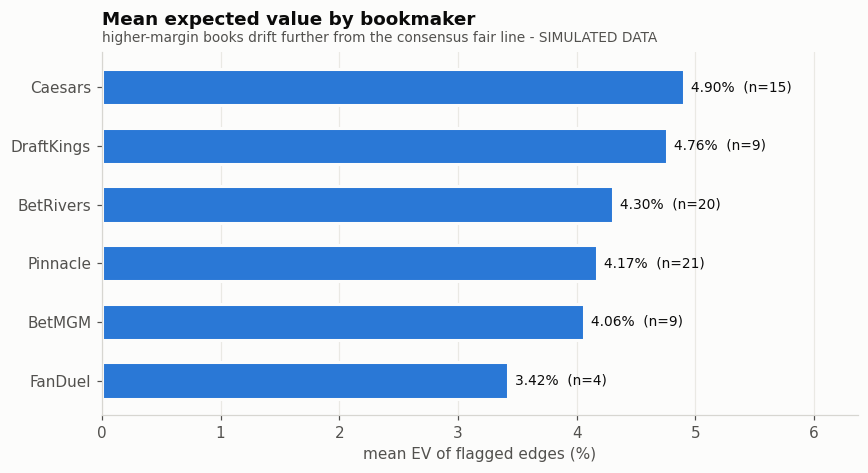

In [20]:
by_book = (df.groupby("bookmaker")
             .agg(mean_ev=("ev", "mean"), count=("ev", "size"))
             .sort_values("mean_ev"))

fig, ax = plt.subplots(figsize=(8, 4.4))
bars = ax.barh(by_book.index, by_book.mean_ev * 100, color=SERIES[0],
               height=0.62, edgecolor=SURFACE, linewidth=2)
for y, (name, row) in enumerate(by_book.iterrows()):
    ax.text(row.mean_ev * 100 + 0.06, y, f"{row.mean_ev * 100:.2f}%  (n={int(row['count'])})",
            va="center", fontsize=9, color=INK)
ax.set_xlim(0, by_book.mean_ev.max() * 100 * 1.30)
finish(ax, "Mean expected value by bookmaker",
       "higher-margin books drift further from the consensus fair line - SIMULATED DATA",
       "mean EV of flagged edges (%)", None, axis="x")
plt.savefig(ASSETS / "notebook_ev_by_book.png", bbox_inches="tight")
plt.show()

In [21]:
by_market = (df.groupby(["sport", "game"])
               .agg(mean_ev=("ev", "mean"), max_ev=("ev", "max"), n=("ev", "size"))
               .reset_index().sort_values("mean_ev", ascending=False))
print("edges by market  [SIMULATED]")
by_market.style.format({"mean_ev": "{:+.2%}", "max_ev": "{:+.2%}"}).hide(axis="index")

edges by market  [SIMULATED]


sport,game,mean_ev,max_ev,n
basketball_nba,Knicks v Boston Celtics,+4.82%,+10.13%,26
americanfootball_nfl,KC Chiefs v Bills,+4.14%,+8.33%,28
icehockey_nhl,NY Rangers v LA Kings,+4.12%,+10.18%,24


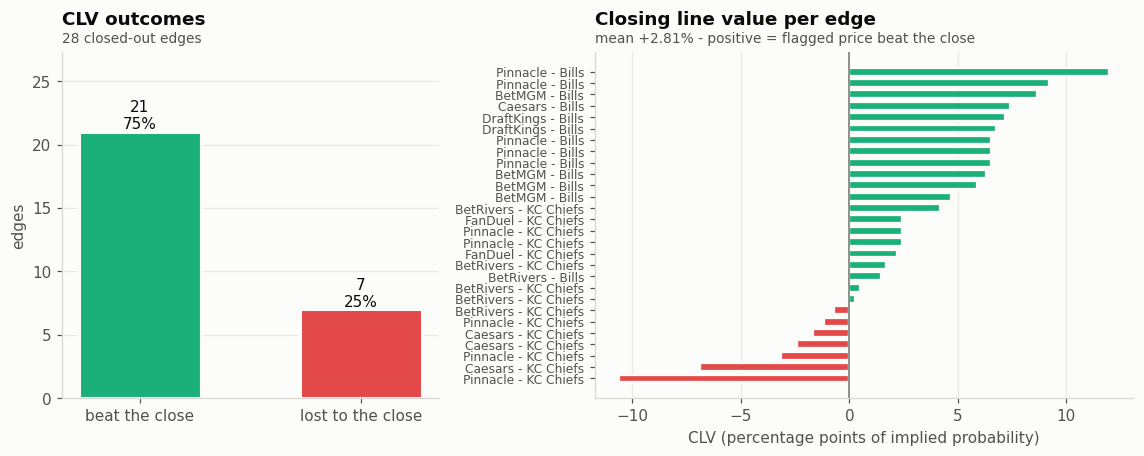

SIMULATED DATA - synthetic market, not a real bookmaker feed.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4),
                         gridspec_kw={"width_ratios": [1.05, 1.5]})

# left: how many edges beat the close
counts = [int(clv.beat_close.sum()), int((~clv.beat_close).sum())]
axes[0].bar(["beat the close", "lost to the close"], counts,
            color=[GOOD, BAD], width=0.55, edgecolor=SURFACE, linewidth=2)
for i, c in enumerate(counts):
    axes[0].text(i, c, f"{c}\n{c / len(clv):.0%}", ha="center", va="bottom",
                 fontsize=10, color=INK)
axes[0].set_ylim(0, max(counts) * 1.30)
finish(axes[0], "CLV outcomes", f"{len(clv)} closed-out edges", None, "edges")

# right: CLV magnitude per closed-out edge
s = clv.sort_values("clv_pct").reset_index(drop=True)
axes[1].barh(range(len(s)), s.clv_pct * 100,
             color=[GOOD if v > 0 else BAD for v in s.clv_pct],
             height=0.7, edgecolor=SURFACE, linewidth=1.5)
axes[1].axvline(0, color=NEUTRAL, lw=1.2)
axes[1].set_yticks(range(len(s)))
axes[1].set_yticklabels([f"{r.bookmaker} - {r.outcome}" for r in s.itertuples()], fontsize=8)
finish(axes[1], "Closing line value per edge",
       f"mean {clv.clv_pct.mean():+.2%} - positive = flagged price beat the close",
       "CLV (percentage points of implied probability)", None, axis="x")

fig.suptitle("")
plt.savefig(ASSETS / "notebook_clv_outcomes.png", bbox_inches="tight")
plt.show()
print("SIMULATED DATA - synthetic market, not a real bookmaker feed.")

## 9. Summary

We ran the full LineEdge pipeline end to end using the real application modules:

| Stage | Module |
|---|---|
| synthetic market | `scripts/market_sim.py` |
| ingestion | `app/ingestion/mock_provider.py` |
| entity resolution | `app/engine/resolver.py` |
| devig / EV / Kelly | `app/engine/math_utils.py` |
| edge detection + dedupe | `app/services/detection_service.py` |
| persistence | `app/storage/database.py`, `app/storage/models.py`, `app/storage/repository.py` |
| CLV closeout | `app/storage/auditor.py` |

### Final reminder

Every price, edge, EV number and CLV figure in this notebook was produced by a
synthetic generator. LineEdge has **no bookmaker integration** — no live odds
feed is connected, and the numbers here say nothing about any real market. This
project is an engineering demonstration of a detection pipeline. **It is not
betting advice and not financial advice.**

In [23]:
print(f"edges detected     : {len(df)}")
print(f"markets            : {df.game.nunique()} games / {df.sport.nunique()} sports")
print(f"books flagged      : {df.bookmaker.nunique()}")
print(f"mean EV            : {df.ev.mean():+.3%}")
print(f"closed out (CLV)   : {len(clv)}  |  beat the close: {clv.beat_close.mean():.1%}")
print(f"charts written to  : {ASSETS}")
print("\nALL FIGURES ABOVE ARE SIMULATED. Not financial advice.")

edges detected     : 78
markets            : 3 games / 3 sports
books flagged      : 6
mean EV            : +4.364%
closed out (CLV)   : 28  |  beat the close: 75.0%
charts written to  : C:\Users\thoma\sports-betting-app\docs\assets

ALL FIGURES ABOVE ARE SIMULATED. Not financial advice.
